In [1]:
from google.colab import drive
import zipfile
import os

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
dataset_path ="/content/drive/MyDrive/archive_cat_dog.zip"

In [4]:
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall('/content/cat_dog_dataset')

In [5]:
data_dir ='/content/cat_dog_dataset'

In [6]:
print("Files in dataset folder:", os.listdir(data_dir))

Files in dataset folder: ['test_set', 'training_set']


In [7]:
import tensorflow as tf
from tensorflow.keras.layers import Conv2D, MaxPooling2D, AveragePooling2D, Flatten, Dense, Dropout, Input, concatenate
from tensorflow.keras.models import Model
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

In [8]:
def inception_module(x, filters):
    f1, f2_in, f2_out, f3_in, f3_out, f4 = filters

    # 1x1 Convolution
    conv1 = Conv2D(f1, (1,1), padding='same', activation='relu')(x)

    # 1x1 followed by 3x3 Convolution
    conv3 = Conv2D(f2_in, (1,1), padding='same', activation='relu')(x)
    conv3 = Conv2D(f2_out, (3,3), padding='same', activation='relu')(conv3)

    # 1x1 followed by 5x5 Convolution
    conv5 = Conv2D(f3_in, (1,1), padding='same', activation='relu')(x)
    conv5 = Conv2D(f3_out, (5,5), padding='same', activation='relu')(conv5)

    # 3x3 Max Pooling followed by 1x1 Convolution
    pool = MaxPooling2D((3,3), strides=(1,1), padding='same')(x)
    pool = Conv2D(f4, (1,1), padding='same', activation='relu')(pool)

    # Concatenate all sub-blocks
    output = concatenate([conv1, conv3, conv5, pool], axis=-1)

    return output

In [9]:
def create_googlenet():
    input_layer = Input(shape=(224, 224, 3))

    x = Conv2D(64, (7,7), strides=(2,2), padding='same', activation='relu')(input_layer)
    x = MaxPooling2D((3,3), strides=(2,2), padding='same')(x)

    x = Conv2D(192, (3,3), padding='same', activation='relu')(x)
    x = MaxPooling2D((3,3), strides=(2,2), padding='same')(x)

    x = inception_module(x, (64, 96, 128, 16, 32, 32))  # Inception 3a
    x = inception_module(x, (128, 128, 192, 32, 96, 64))  # Inception 3b
    x = MaxPooling2D((3,3), strides=(2,2), padding='same')(x)

    x = inception_module(x, (192, 96, 208, 16, 48, 64))  # Inception 4a
    x = inception_module(x, (160, 112, 224, 24, 64, 64))  # Inception 4b
    x = inception_module(x, (128, 128, 256, 24, 64, 64))  # Inception 4c
    x = inception_module(x, (112, 144, 288, 32, 64, 64))  # Inception 4d
    x = inception_module(x, (256, 160, 320, 32, 128, 128))  # Inception 4e
    x = MaxPooling2D((3,3), strides=(2,2), padding='same')(x)

    x = inception_module(x, (256, 160, 320, 32, 128, 128))  # Inception 5a
    x = inception_module(x, (384, 192, 384, 48, 128, 128))  # Inception 5b

    x = AveragePooling2D((7,7), strides=(1,1))(x)
    x = Flatten()(x)
    x = Dropout(0.4)(x)
    x = Dense(1, activation='sigmoid')(x)  # Binary classification

    model = Model(inputs=input_layer, outputs=x)
    return model

In [10]:
model = create_googlenet()

In [11]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 112, 112, 64)   │          9,472 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 56, 56, 64)     │              0 │ conv2d[0][0]           │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 56, 56, 192)    │        110,784 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 28, 28, 192)    │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 28, 28, 96)     │         18,528 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 28, 28, 16)     │          3,088 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 28, 28, 192)    │              0 │ max_pooling2d_1[0][0]  │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 28, 28, 64)     │         12,352 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 28, 28, 128)    │        110,720 │ conv2d_3[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 28, 28, 32)     │         12,832 │ conv2d_5[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 28, 28, 32)     │          6,176 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ concatenate (Concatenate) │ (None, 28, 28, 256)    │              0 │ conv2d_2[0][0],        │
│                           │                        │                │ conv2d_4[0][0],        │
│                           │                        │                │ conv2d_6[0][0],        │
│                           │                        │                │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 28, 28, 128)    │         32,896 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 28, 28, 32)     │          8,224 │ concatenate[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 28, 28, 256)    │              0 │ concatenate[0][0]      │
│ (MaxPooling2D)            │                        │                │                        │
├──────────────────────

 Total params: 5,970,417 (22.78 MB)

 Trainable params: 5,970,417 (22.78 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
train_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)
test_datagen = ImageDataGenerator(rescale=1./255)

In [14]:
train_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

Found 6404 images belonging to 2 classes.


In [15]:
val_generator = train_datagen.flow_from_directory(
    '/content/cat_dog_dataset/training_set/training_set',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 1601 images belonging to 2 classes.


In [16]:
test_generator = test_datagen.flow_from_directory(
    '/content/cat_dog_dataset/test_set/test_set',
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2023 images belonging to 2 classes.


In [17]:
history = model.fit(train_generator, validation_data=val_generator, epochs=10)

Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:122: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


201/201 ━━━━━━━━━━━━━━━━━━━━ 97s 264ms/step - accuracy: 0.4882 - loss: 0.6966 - val_accuracy: 0.5003 - val_loss: 0.6932
Epoch 2/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 30s 124ms/step - accuracy: 0.4983 - loss: 0.6934 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 3/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 26s 127ms/step - accuracy: 0.5075 - loss: 0.6931 - val_accuracy: 0.5003 - val_loss: 0.6932
Epoch 4/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 40s 125ms/step - accuracy: 0.5038 - loss: 0.6930 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 5/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 26s 129ms/step - accuracy: 0.4968 - loss: 0.6932 - val_accuracy: 0.5003 - val_loss: 0.6931
Epoch 6/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 27s 133ms/step - accuracy: 0.5003 - loss: 0.6932 - val_accuracy: 0.5003 - val_loss: 0.6932
Epoch 7/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 25s 123ms/step - accuracy: 0.5053 - loss: 0.6932 - val_accuracy: 0.4997 - val_loss: 0.6932
Epoch 8/10
201/201 ━━━━━━━━━━━━━━━━━━━━ 42s 127ms/step - accuracy: 0.5142 - loss: 0.6929 - val

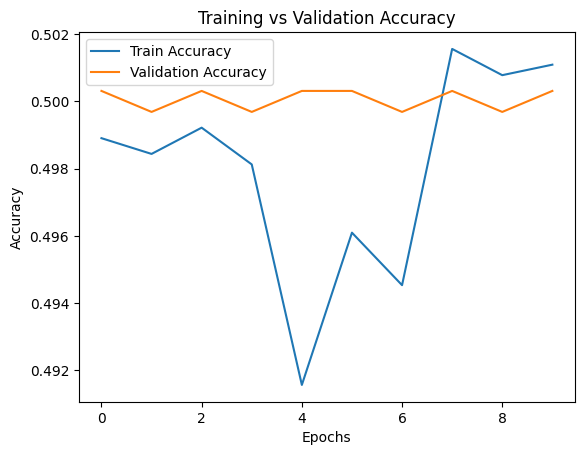

In [18]:
# Plot training history
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training vs Validation Accuracy')
plt.show()

In [19]:
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc:.4f}")

64/64 ━━━━━━━━━━━━━━━━━━━━ 8s 129ms/step - accuracy: 0.1670 - loss: 0.6969
Test Accuracy: 0.5002
